# Test Metrics

Evaluate the configured 3-channel and 5-channel `val_IoU` checkpoints on the held-out test split.

## Evaluation Metrics

This notebook evaluates semantic segmentation models using overlap-based pixel metrics. The primary metric is **mean Intersection-over-Union (mIoU)** because each pixel is assigned exactly one semantic class, and the main goal is to measure spatial overlap between predicted and ground-truth regions.

Reported metrics:

- **Pixel Accuracy**: Fraction of valid pixels classified correctly. This is intuitive, but can be dominated by large/common classes.
- **Per-class IoU**: Intersection-over-union for each class: true overlap divided by the union of predicted and true pixels.
- **Mean IoU (mIoU)**: Average IoU across classes. This is the primary metric because it treats each class more equally than pixel accuracy.
- **Per-class Dice**: Dice/F1-style overlap for each class.
- **Mean Dice**: Average Dice score across classes. This is a secondary overlap metric that is often easier to interpret alongside IoU.
- **Latency / Patch**: Mean model-forward inference time per image patch, excluding warmup batches. This is a secondary efficiency metric.
- **Support**: Number of ground-truth pixels for each class. This helps identify class imbalance.

We intentionally do **not** report mAP as a main metric. Mean Average Precision is more common for object detection and instance segmentation, where models predict separate object instances with confidence scores. For this semantic segmentation task, mIoU and Dice are more directly aligned with the final hard segmentation masks.

## Setup

In [1]:
# from google.colab import drive
# drive.mount("/content/drive")
# %cd /content/drive/MyDrive/Deep\ Learning\ Project/DLE-Flair-Segmentation

# !pip install -r requirements.txt -q

In [2]:
from pathlib import Path
import sys

import torch
from IPython.display import Markdown, display

CWD = Path.cwd()
if (CWD / "src").exists():
    REPO_ROOT = CWD
elif (CWD.parent / "src").exists():
    REPO_ROOT = CWD.parent
else:
    raise RuntimeError("Could not find repo root containing src/.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data import build_dataloaders
from src.evaluate import evaluate_test_metrics, load_checkpoint_model
from src.train import sync_class_config
from src.utils import get_device, load_config, markdown_table
from src.visualize import plot_confusion_matrix

device = get_device()
device

device(type='cuda')

## Load Config

In [3]:
metrics_config = load_config(REPO_ROOT / "configs" / "test_metrics.yaml")
class_names = metrics_config["class_names"]
metrics_settings = metrics_config.get("metrics", {})
ignore_index = metrics_settings.get("ignore_index", 255)
latency_warmup_batches = metrics_settings.get("latency_warmup_batches", 1)
viz_config = metrics_config.get("visualization", {})
normalize_confusion_matrix = viz_config.get("normalize_confusion_matrix", True)
viz_output_dir = REPO_ROOT / viz_config.get("output_dir", "notebooks/outputs/test_metrics/")
viz_output_dir.mkdir(parents=True, exist_ok=True)

[(entry["name"], entry["label"], entry["checkpoint"]) for entry in metrics_config["models"]]

[('resnet34_unet_5ch',
  'ResNet34-UNet (5ch)',
  'notebooks/outputs/resnet34_unet_5ch_val_IoU/best.pt'),
 ('resnet34_unet_3ch',
  'ResNet34-UNet (3ch)',
  'notebooks/outputs/resnet34_unet_3ch_valIoU/best.pt'),
 ('convnext_tiny_3ch',
  'ConvNeXt-Tiny (3ch)',
  'notebooks/outputs/convnext_tiny_3ch_val_IoU/best.pt'),
 ('convnext_tiny_5ch',
  'ConvNeXt-Tiny (5ch)',
  'notebooks/outputs/convnext_tiny_5ch_val_IoU/best.pt'),
 ('dinov3_convnext_5ch',
  'DINOv3-ConvNeXt-Tiny (5ch)',
  'notebooks/outputs/dinov3_convnext_tiny_5ch_val_IoU/best.pt'),
 ('dinov3_convnext_3ch',
  'DINOv3-ConvNeXt-Tiny (3ch)',
  'notebooks/outputs/dinov3_convnext_tiny_3ch_val_IoU/best.pt')]

## Channel Selection Note

The 3-channel models are evaluated on the same configured channels they were trained on, and the 5-channel models are evaluated on their configured 5-channel inputs. FLAIR raster channels are 1-indexed in the dataloader config.

## Evaluation Helper

In [4]:
def evaluate_model_entry(entry):
    train_config = sync_class_config(load_config(REPO_ROOT / entry["config"]))
    train_config["model"]["in_channels"] = entry["in_channels"]
    train_config["model"]["num_classes"] = entry["num_classes"]
    train_config["data"]["num_classes"] = entry["num_classes"]

    configured_channels = train_config["data"]["channels"]
    if len(configured_channels) != entry["in_channels"]:
        raise ValueError(
            f"{entry['label']} expects {entry['in_channels']} channels, "
            f"but config has channels={configured_channels}."
        )

    _, _, test_loader = build_dataloaders(train_config["data"])
    model, checkpoint = load_checkpoint_model(
        REPO_ROOT / entry["checkpoint"],
        device=device,
        model_config=train_config["model"],
    )

    metrics = evaluate_test_metrics(
        model=model,
        dataloader=test_loader,
        num_classes=entry["num_classes"],
        device=device,
        ignore_index=ignore_index,
        class_names=class_names,
        latency_warmup_batches=latency_warmup_batches,
    )

    return {
        "entry": entry,
        "checkpoint": checkpoint,
        "metrics": metrics,
    }

## Run Evaluation

In [5]:
results = []
for entry in metrics_config["models"]:
    print(f"Evaluating {entry['label']} from {entry['checkpoint']}")
    results.append(evaluate_model_entry(entry))

len(results)

Evaluating ResNet34-UNet (5ch) from notebooks/outputs/resnet34_unet_5ch_val_IoU/best.pt


Evaluating test metrics: 100%|██████████| 4/4 [00:00<00:00,  8.92it/s]


Evaluating ResNet34-UNet (3ch) from notebooks/outputs/resnet34_unet_3ch_valIoU/best.pt


Evaluating test metrics: 100%|██████████| 4/4 [00:00<00:00, 17.44it/s]


Evaluating ConvNeXt-Tiny (3ch) from notebooks/outputs/convnext_tiny_3ch_val_IoU/best.pt


...

Evaluating test metrics: 100%|██████████| 4/4 [00:00<00:00, 16.47it/s]


Evaluating DINOv3-ConvNeXt-Tiny (3ch) from notebooks/outputs/dinov3_convnext_tiny_3ch_val_IoU/best.pt


Loading weights:   0%|          | 0/180 [00:00<?, ?it/s]

Evaluating test metrics: 100%|██████████| 4/4 [00:00<00:00, 19.06it/s]


6

## Summary Metrics

In [6]:
summary_rows = []
for result in results:
    entry = result["entry"]
    metrics = result["metrics"]
    summary_rows.append({
        "model": entry["label"],
        "input_channels": entry["in_channels"],
        "pixel_accuracy": metrics["pixel_accuracy"],
        "mIoU": metrics["mIoU"],
        "mean_dice": metrics["mean_dice"],
        "latency_ms_per_patch": metrics["latency_ms_per_patch"],
    })

markdown_table(
    summary_rows,
    [
        ("model", "Model"),
        ("input_channels", "Input Channels"),
        ("pixel_accuracy", "Pixel Acc"),
        ("mIoU", "mIoU"),
        ("mean_dice", "Mean Dice"),
        ("latency_ms_per_patch", "Latency / Patch (ms)"),
    ],
)

| Model | Input Channels | Pixel Acc | mIoU | Mean Dice | Latency / Patch (ms) |
| --- | --- | --- | --- | --- | --- |
| ResNet34-UNet (5ch) | 5 | 0.7172 | 0.4361 | 0.5540 | 6.2137 |
| ResNet34-UNet (3ch) | 3 | 0.7286 | 0.4605 | 0.5885 | 4.7184 |
| ConvNeXt-Tiny (3ch) | 3 | 0.6925 | 0.4466 | 0.5710 | 19.9381 |
| ConvNeXt-Tiny (5ch) | 5 | 0.7195 | 0.4837 | 0.6254 | 5.5917 |
| DINOv3-ConvNeXt-Tiny (5ch) | 5 | 0.7195 | 0.4914 | 0.6056 | 5.2108 |
| DINOv3-ConvNeXt-Tiny (3ch) | 3 | 0.7246 | 0.4782 | 0.6041 | 4.7728 |

## Class Support

Class support shows how many ground-truth pixels belong to each class. This matters because pixel accuracy can be dominated by large classes, while small classes may have poor IoU even if overall accuracy looks high.

In [7]:
support_rows = []
first_class_rows = results[0]["metrics"]["class_rows"]
total_support = sum(row["support_pixels"] for row in first_class_rows)
for row in first_class_rows:
    support_rows.append({
        "class_id": row["class_id"],
        "class_name": row["class_name"],
        "support_pixels": row["support_pixels"],
        "support_percent": row["support_pixels"] / total_support if total_support else 0.0,
    })

markdown_table(
    support_rows,
    [
        ("class_id", "ID"),
        ("class_name", "Class"),
        ("support_pixels", "Support Pixels"),
        ("support_percent", "Support %"),
    ],
)

| ID | Class | Support Pixels | Support % |
| --- | --- | --- | --- |
| 0 | Built (Non-vegetated) | 2233316 | 0.3408 |
| 1 | Bare (Non-vegetated) | 270954 | 0.0413 |
| 2 | Woody Vegetation | 1656028 | 0.2527 |
| 3 | Agriculture | 882872 | 0.1347 |
| 4 | Herbaceous Vegetation | 1066132 | 0.1627 |
| 5 | Water | 444298 | 0.0678 |

## Best Model Summary

In [8]:
best_by_miou = max(summary_rows, key=lambda row: row["mIoU"])
best_by_dice = max(summary_rows, key=lambda row: row["mean_dice"])
best_by_acc = max(summary_rows, key=lambda row: row["pixel_accuracy"])
fastest_by_latency = min(summary_rows, key=lambda row: row["latency_ms_per_patch"])

display(Markdown(f"""
- Best by **mIoU**: `{best_by_miou["model"]}` with `{best_by_miou["mIoU"]:.4f}`
- Best by **Mean Dice**: `{best_by_dice["model"]}` with `{best_by_dice["mean_dice"]:.4f}`
- Best by **Pixel Accuracy**: `{best_by_acc["model"]}` with `{best_by_acc["pixel_accuracy"]:.4f}`
- Fastest by **Latency / Patch**: `{fastest_by_latency["model"]}` with `{fastest_by_latency["latency_ms_per_patch"]:.4f}` ms

Semantic segmentation task, so **mIoU is treated as the primary metric**. Latency is a secondary inference-efficiency metric.
"""))


- Best by **mIoU**: `DINOv3-ConvNeXt-Tiny (5ch)` with `0.4914`
- Best by **Mean Dice**: `ConvNeXt-Tiny (5ch)` with `0.6254`
- Best by **Pixel Accuracy**: `ResNet34-UNet (3ch)` with `0.7286`
- Fastest by **Latency / Patch**: `ResNet34-UNet (3ch)` with `4.7184` ms

Semantic segmentation task, so **mIoU is treated as the primary metric**. Latency is a secondary inference-efficiency metric.


## Per-Class Metrics

In [9]:
for result in results:
    entry = result["entry"]
    display(Markdown(f"### {entry['label']}"))
    markdown_table(
        result["metrics"]["class_rows"],
        [
            ("class_id", "ID"),
            ("class_name", "Class"),
            ("support_pixels", "Support"),
            ("predicted_pixels", "Predicted"),
            ("iou", "IoU"),
            ("dice", "Dice"),
        ],
    )

### ResNet34-UNet (5ch)

| ID | Class | Support | Predicted | IoU | Dice |
| --- | --- | --- | --- | --- | --- |
| 0 | Built (Non-vegetated) | 2233316 | 3160054 | 0.6599 | 0.7951 |
| 1 | Bare (Non-vegetated) | 270954 | 96337 | 0.0331 | 0.0642 |
| 2 | Woody Vegetation | 1656028 | 1543289 | 0.7027 | 0.8254 |
| 3 | Agriculture | 882872 | 1161097 | 0.6852 | 0.8132 |
| 4 | Herbaceous Vegetation | 1066132 | 319485 | 0.1688 | 0.2888 |
| 5 | Water | 444298 | 273338 | 0.3671 | 0.5371 |

### ResNet34-UNet (3ch)

| ID | Class | Support | Predicted | IoU | Dice |
| --- | --- | --- | --- | --- | --- |
| 0 | Built (Non-vegetated) | 2233316 | 2928375 | 0.6889 | 0.8158 |
| 1 | Bare (Non-vegetated) | 270954 | 88690 | 0.0590 | 0.1113 |
| 2 | Woody Vegetation | 1656028 | 1940507 | 0.6930 | 0.8186 |
| 3 | Agriculture | 882872 | 629565 | 0.6559 | 0.7922 |
| 4 | Herbaceous Vegetation | 1066132 | 719496 | 0.2733 | 0.4293 |
| 5 | Water | 444298 | 246967 | 0.3928 | 0.5640 |

### ConvNeXt-Tiny (3ch)

...

| ID | Class | Support | Predicted | IoU | Dice |
| --- | --- | --- | --- | --- | --- |
| 0 | Built (Non-vegetated) | 2233316 | 2973550 | 0.6397 | 0.7803 |
| 1 | Bare (Non-vegetated) | 270954 | 59729 | 0.2195 | 0.3600 |
| 2 | Woody Vegetation | 1656028 | 1739961 | 0.6456 | 0.7846 |
| 3 | Agriculture | 882872 | 782752 | 0.7574 | 0.8620 |
| 4 | Herbaceous Vegetation | 1066132 | 749328 | 0.2720 | 0.4276 |
| 5 | Water | 444298 | 248280 | 0.3681 | 0.5381 |

### DINOv3-ConvNeXt-Tiny (5ch)

| ID | Class | Support | Predicted | IoU | Dice |
| --- | --- | --- | --- | --- | --- |
| 0 | Built (Non-vegetated) | 2233316 | 2635632 | 0.6454 | 0.7845 |
| 1 | Bare (Non-vegetated) | 270954 | 4935 | 0.0021 | 0.0041 |
| 2 | Woody Vegetation | 1656028 | 1784575 | 0.6248 | 0.7690 |
| 3 | Agriculture | 882872 | 752430 | 0.8006 | 0.8892 |
| 4 | Herbaceous Vegetation | 1066132 | 1056867 | 0.2857 | 0.4444 |
| 5 | Water | 444298 | 319161 | 0.5902 | 0.7423 |

### DINOv3-ConvNeXt-Tiny (3ch)

| ID | Class | Support | Predicted | IoU | Dice |
| --- | --- | --- | --- | --- | --- |
| 0 | Built (Non-vegetated) | 2233316 | 2901637 | 0.6350 | 0.7767 |
| 1 | Bare (Non-vegetated) | 270954 | 16288 | 0.0594 | 0.1121 |
| 2 | Woody Vegetation | 1656028 | 1747384 | 0.6544 | 0.7911 |
| 3 | Agriculture | 882872 | 773711 | 0.7958 | 0.8863 |
| 4 | Herbaceous Vegetation | 1066132 | 839269 | 0.3051 | 0.4675 |
| 5 | Water | 444298 | 275311 | 0.4195 | 0.5910 |

## 3ch vs 5ch Deltas

In [10]:
result_by_name = {result["entry"]["name"]: result for result in results}
model_pairs = [
    ("ResNet34-UNet", "resnet34_unet_3ch", "resnet34_unet_5ch"),
    ("ConvNeXt-Tiny", "convnext_tiny_3ch", "convnext_tiny_5ch"),
    ("DINOv3-ConvNeXt-Tiny", "dinov3_convnext_3ch", "dinov3_convnext_5ch"),
]

delta_rows = []
for family, three_name, five_name in model_pairs:
    three = result_by_name[three_name]["metrics"]
    five = result_by_name[five_name]["metrics"]
    delta_rows.append({
        "family": family,
        "mIoU_3ch": three["mIoU"],
        "mIoU_5ch": five["mIoU"],
        "delta_mIoU": five["mIoU"] - three["mIoU"],
        "dice_3ch": three["mean_dice"],
        "dice_5ch": five["mean_dice"],
        "delta_dice": five["mean_dice"] - three["mean_dice"],
        "acc_3ch": three["pixel_accuracy"],
        "acc_5ch": five["pixel_accuracy"],
        "delta_acc": five["pixel_accuracy"] - three["pixel_accuracy"],
        "latency_3ch": three["latency_ms_per_patch"],
        "latency_5ch": five["latency_ms_per_patch"],
        "delta_latency": five["latency_ms_per_patch"] - three["latency_ms_per_patch"],
    })

print("Delta is computed as (5-channel) - (3-channel); positive means the 5-channel model has a higher value.")
markdown_table(
    delta_rows,
    [
        ("family", "Model Family"),
        ("mIoU_3ch", "3ch mIoU"),
        ("mIoU_5ch", "5ch mIoU"),
        ("delta_mIoU", "Delta mIoU"),
        ("dice_3ch", "3ch Dice"),
        ("dice_5ch", "5ch Dice"),
        ("delta_dice", "Delta Dice"),
        ("acc_3ch", "3ch Acc"),
        ("acc_5ch", "5ch Acc"),
        ("delta_acc", "Delta Acc"),
        ("latency_3ch", "3ch Latency (ms)"),
        ("latency_5ch", "5ch Latency (ms)"),
        ("delta_latency", "Delta Latency (ms)"),
    ],
)

Delta is computed as (5-channel) - (3-channel); positive means the 5-channel model has a higher value.


| Model Family | 3ch mIoU | 5ch mIoU | Delta mIoU | 3ch Dice | 5ch Dice | Delta Dice | 3ch Acc | 5ch Acc | Delta Acc | 3ch Latency (ms) | 5ch Latency (ms) | Delta Latency (ms) |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ResNet34-UNet | 0.4605 | 0.4361 | -0.0243 | 0.5885 | 0.5540 | -0.0346 | 0.7286 | 0.7172 | -0.0114 | 4.7184 | 6.2137 | 1.4953 |
| ConvNeXt-Tiny | 0.4466 | 0.4837 | 0.0371 | 0.5710 | 0.6254 | 0.0544 | 0.6925 | 0.7195 | 0.0270 | 19.9381 | 5.5917 | -14.3464 |
| DINOv3-ConvNeXt-Tiny | 0.4782 | 0.4914 | 0.0132 | 0.6041 | 0.6056 | 0.0015 | 0.7246 | 0.7195 | -0.0051 | 4.7728 | 5.2108 | 0.4381 |

## Per-Class 3ch vs 5ch Deltas

In [11]:
per_class_delta_rows = []
for family, three_name, five_name in model_pairs:
    three_rows = result_by_name[three_name]["metrics"]["class_rows"]
    five_rows = result_by_name[five_name]["metrics"]["class_rows"]
    for three_row, five_row in zip(three_rows, five_rows):
        per_class_delta_rows.append({
            "family": family,
            "class_name": five_row["class_name"],
            "delta_iou": five_row["iou"] - three_row["iou"],
            "delta_dice": five_row["dice"] - three_row["dice"],
        })

markdown_table(
    per_class_delta_rows,
    [
        ("family", "Model Family"),
        ("class_name", "Class"),
        ("delta_iou", "Delta IoU"),
        ("delta_dice", "Delta Dice"),
    ],
)

| Model Family | Class | Delta IoU | Delta Dice |
| --- | --- | --- | --- |
| ResNet34-UNet | Built (Non-vegetated) | -0.0290 | -0.0207 |
| ResNet34-UNet | Bare (Non-vegetated) | -0.0258 | -0.0472 |
| ResNet34-UNet | Woody Vegetation | 0.0097 | 0.0068 |
| ResNet34-UNet | Agriculture | 0.0293 | 0.0210 |
| ResNet34-UNet | Herbaceous Vegetation | -0.1045 | -0.1405 |
| ResNet34-UNet | Water | -0.0257 | -0.0270 |
| ConvNeXt-Tiny | Built (Non-vegetated) | 0.0512 | 0.0393 |
| ConvNeXt-Tiny | Bare (Non-vegetated) | 0.2121 | 0.3453 |
| ConvNeXt-Tiny | Woody Vegetation | 0.0430 | 0.0326 |
| ConvNeXt-Tiny | Agriculture | -0.0011 | -0.0007 |
| ConvNeXt-Tiny | Herbaceous Vegetation | -0.0298 | -0.0360 |
| ConvNeXt-Tiny | Water | -0.0526 | -0.0541 |
| DINOv3-ConvNeXt-Tiny | Built (Non-vegetated) | 0.0104 | 0.0077 |
| DINOv3-ConvNeXt-Tiny | Bare (Non-vegetated) | -0.0573 | -0.1080 |
| DINOv3-ConvNeXt-Tiny | Woody Vegetation | -0.0296 | -0.0220 |
| DINOv3-ConvNeXt-Tiny | Agriculture | 0.0047 | 0.0029 |
| DINOv3-ConvNeXt-Tiny | Herbaceous Vegetation | -0.0194 | -0.0232 |
| DINOv3-ConvNeXt-Tiny | Water | 0.1707 | 0.1512 |

## Confusion Matrices

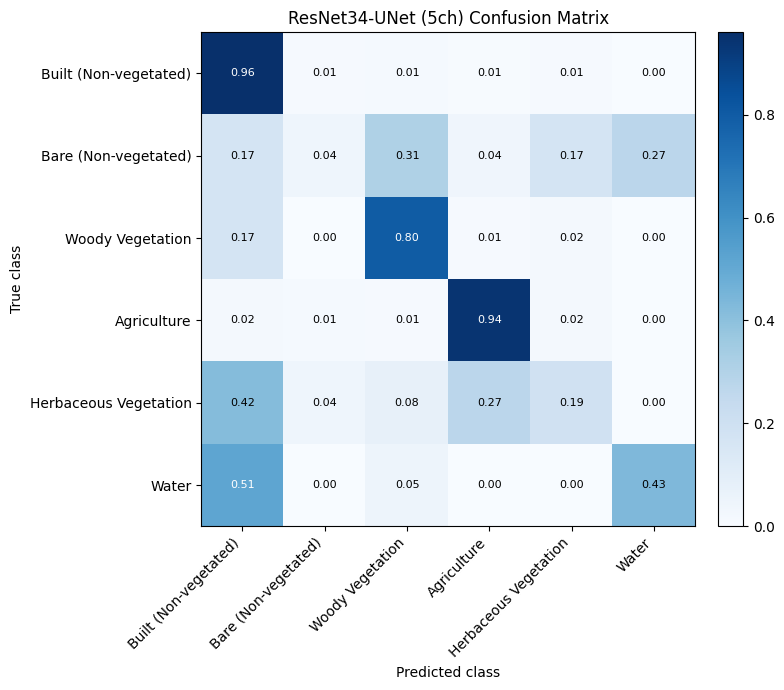

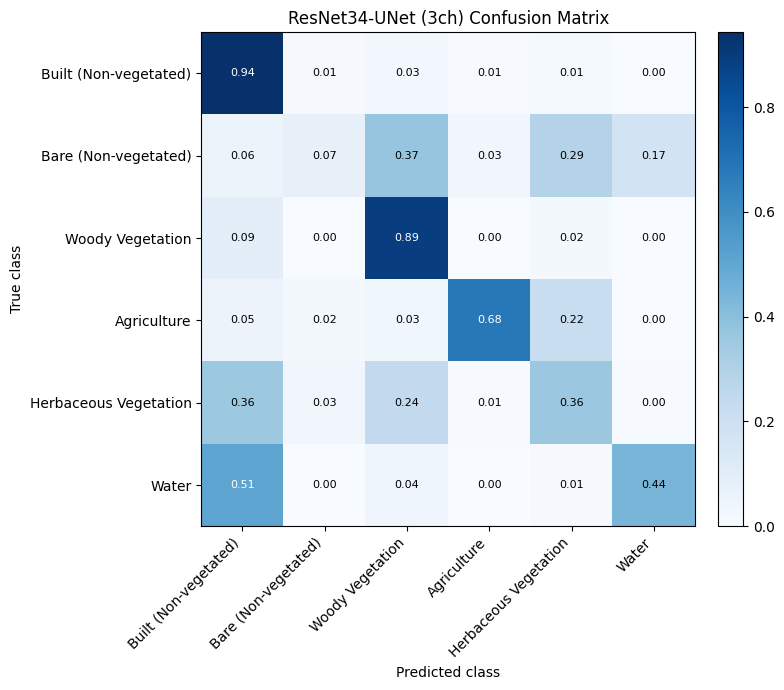

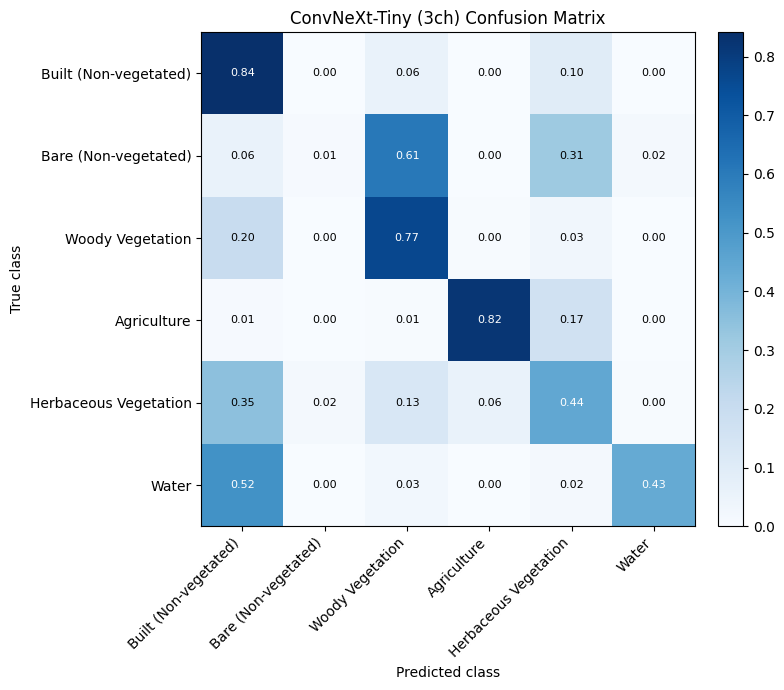

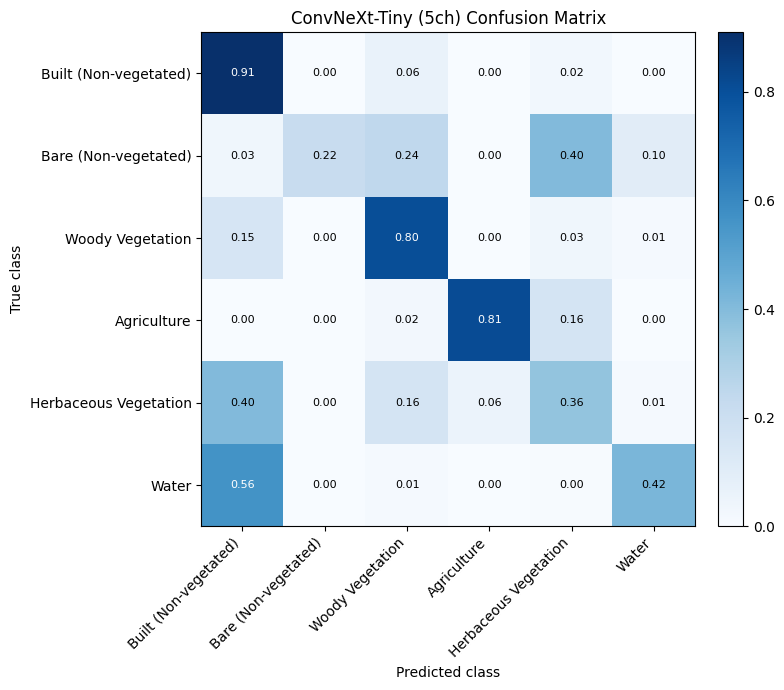

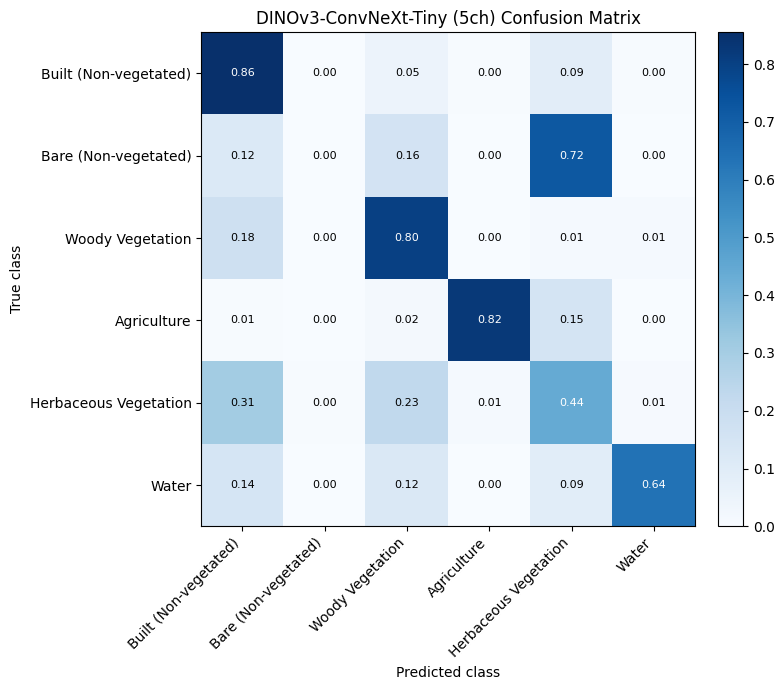

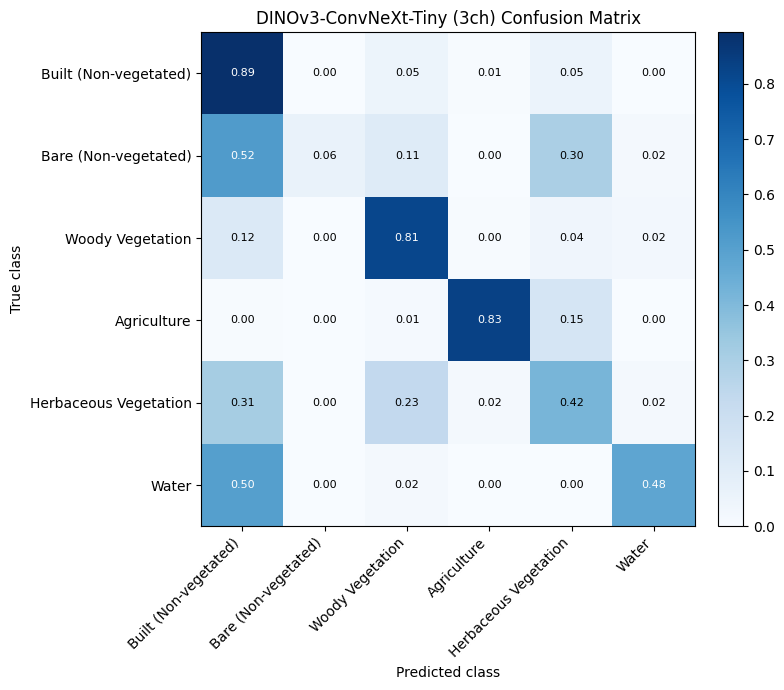

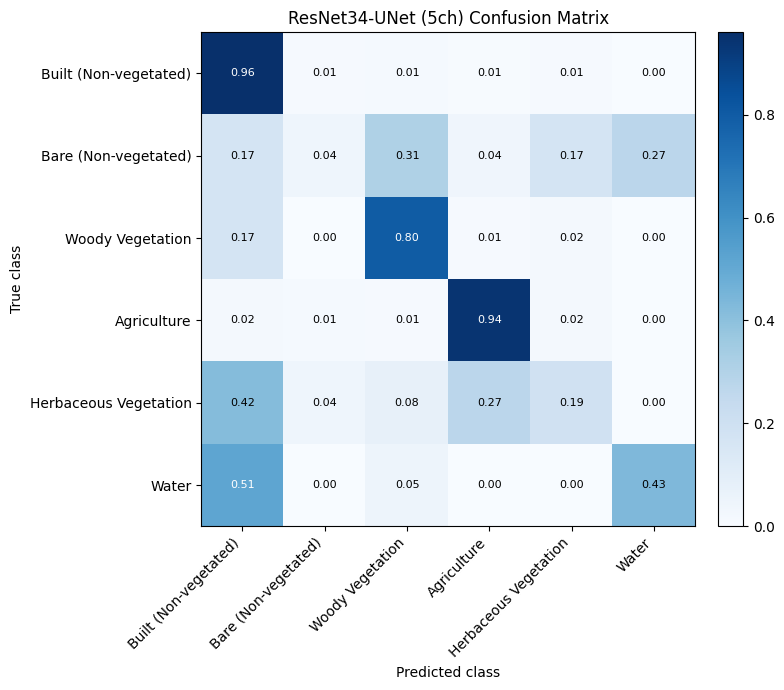

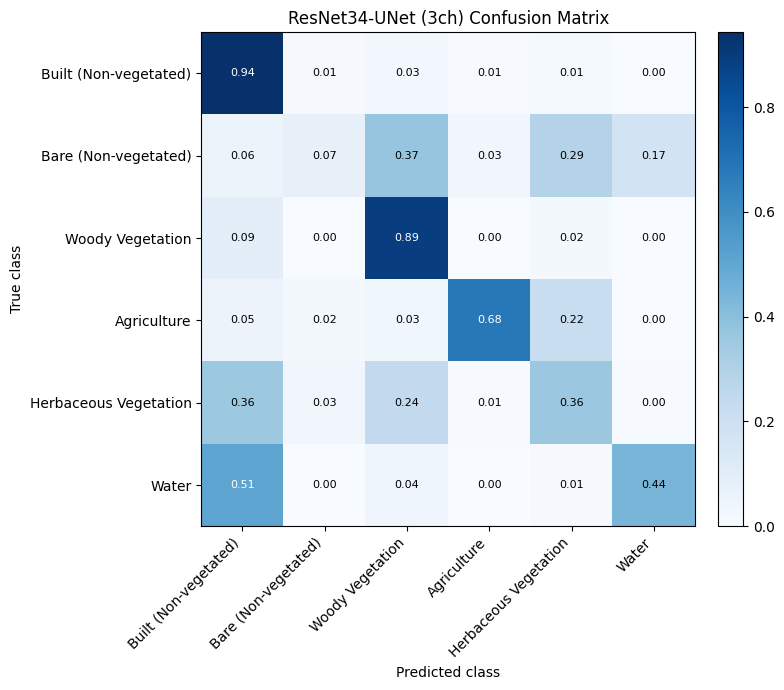

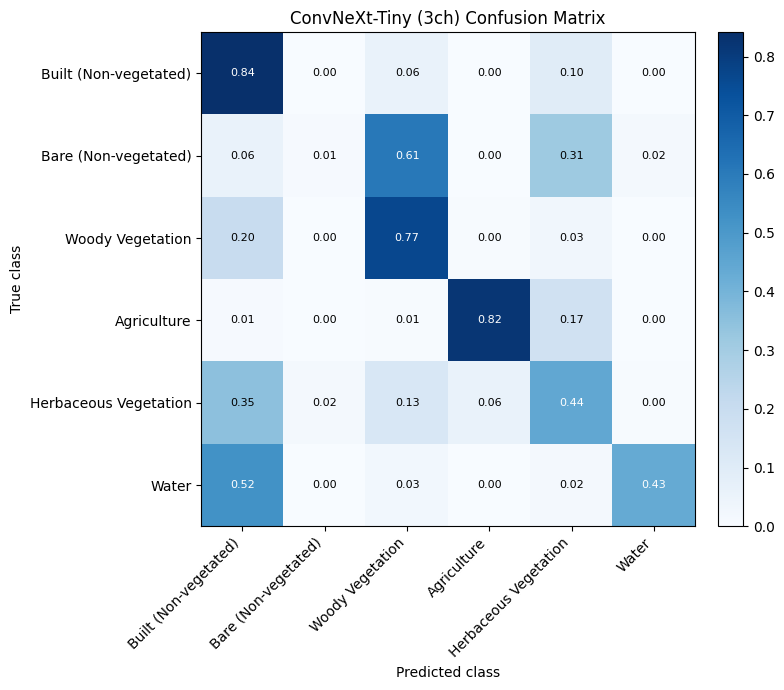

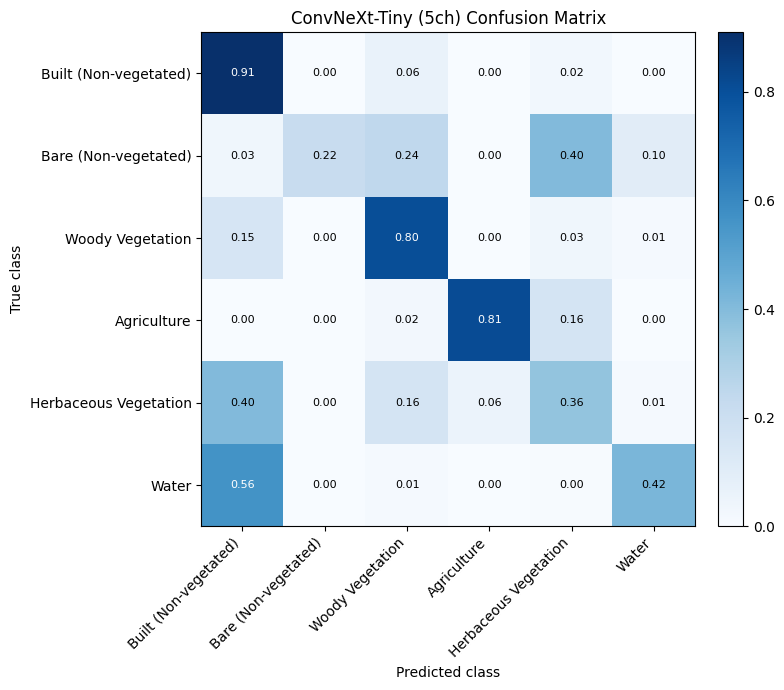

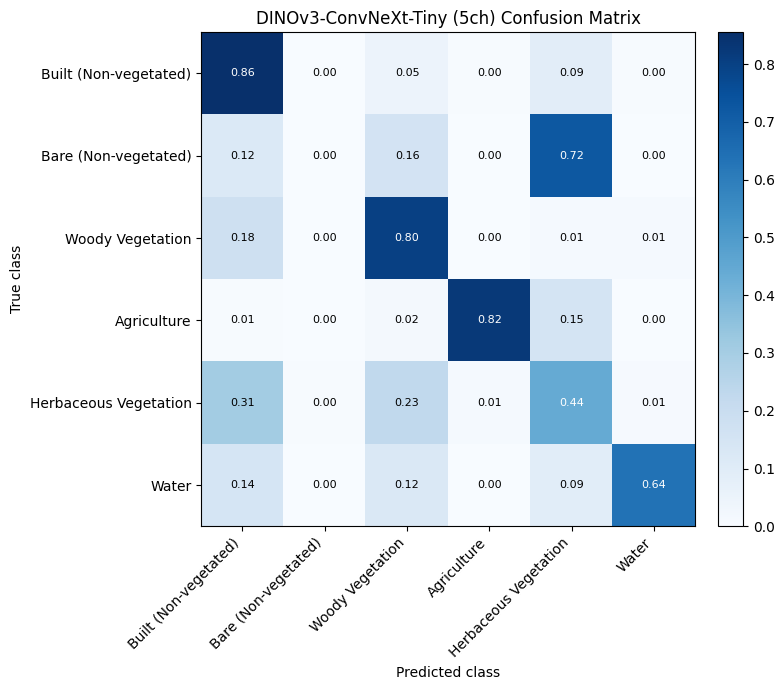

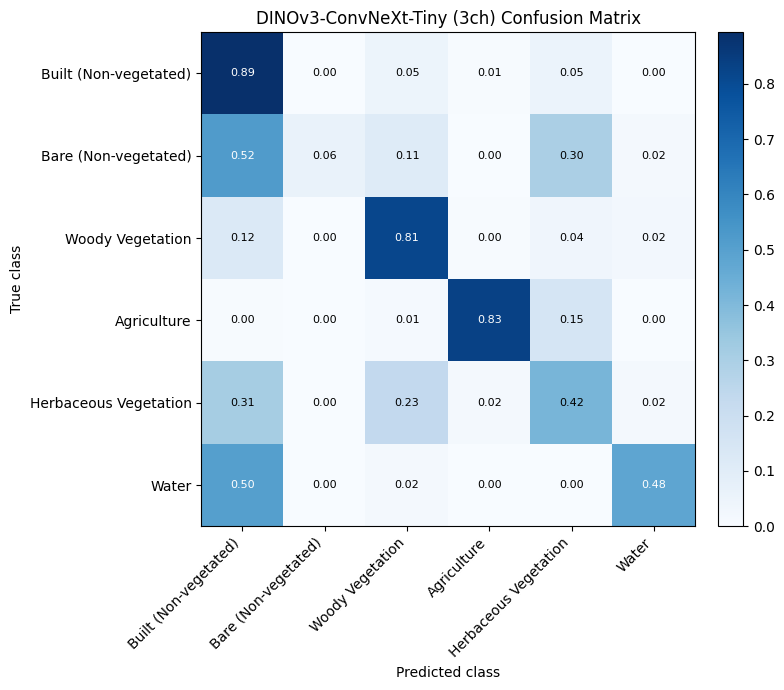

In [12]:
for result in results:
    entry = result["entry"]
    fig = plot_confusion_matrix(
        result["metrics"]["confusion_matrix"],
        class_names=class_names,
        normalize=normalize_confusion_matrix,
        title=f"{entry['label']} Confusion Matrix",
    )
    fig.savefig(viz_output_dir / f"{entry['name']}_confusion_matrix.png", dpi=viz_config.get("dpi", 150), bbox_inches="tight")
    display(fig)

## Interpretation

In [13]:
top = best_by_miou

weakest = sorted(
    results[0]["metrics"]["class_rows"],
    key=lambda row: row["iou"],
)[:2]

print(f"Best model by mIoU: {top['model']} with mIoU={top['mIoU']:.4f}")
print("Weakest classes in first evaluated model:")
for row in weakest:
    print(f"- {row['class_name']} with IoU={row['iou']:.4f}")   

Best model by mIoU: DINOv3-ConvNeXt-Tiny (5ch) with mIoU=0.4914
Weakest classes in first evaluated model:
- Bare (Non-vegetated) with IoU=0.0331
- Herbaceous Vegetation with IoU=0.1688


Primary metric for model performance is mIoU, while mDice and Pixel Accuracy provide secondary metrics / expanded explanations. Pixel accuracy can be misleading, because our classes are very imbalance in the test set.

The best model is shown above. However, the second best model (resnet 5ch) is very close, and model ranking may change based on a larger/different test set with a different class distribution.

3 vs 5 channel comparisons highlight an important observation: they are architecture dependent. Dino, with its internet scale training set, robustly learned two additional channels, where resnet did not see the same benefits. 